<div style="background: linear-gradient(to bottom, #461EBE, #006EC7); padding: 24px 28px; border-radius: 12px; color: white;">

# Dataset Exploration  — `data/icons_filtered.jsonl`
Explores the 275,912 license-filtered icons: monochrome vs. multicolor split,
path count distribution, and SVG string length.

</div>

In [1]:
import json
import re
import sys
from pathlib import Path

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

sys.path.insert(0, "..")
from brand import BRAND, blue, purple, orange, green, pink, teal, white, black, dark_bg

plt.style.use("dark_background")
mpl.rcParams.update({
    "figure.facecolor":  dark_bg,
    "axes.facecolor":    dark_bg,
    "axes.edgecolor":    blue,
    "axes.labelcolor":   white,
    "xtick.color":       white,
    "ytick.color":       white,
    "text.color":        white,
    "legend.framealpha": 1.0,
    "legend.edgecolor":  blue,
    "legend.facecolor":  dark_bg,
    "font.family":       "sans-serif",
})

In [2]:
DATA = Path("../data/icons_filtered.jsonl")

records = []
with open(DATA) as f:
    for line in f:
        if line.strip():
            records.append(json.loads(line))

print(f"Total icons loaded: {len(records):,}")

Total icons loaded: 275,912


In [3]:
_ATTR_COLOR = re.compile(
    r'(?:fill|stroke|stop-color|color)\s*=\s*["\']([^"\']+)["\']',
    re.IGNORECASE,
)
_STYLE_COLOR = re.compile(
    r'(?:fill|stroke|stop-color|color)\s*:\s*([^;"\'\s>]+)',
    re.IGNORECASE,
)
_SKIP_COLORS = frozenset({"currentcolor", "none", "inherit", "transparent", ""})

def _classify(svg: str) -> str:
    vals = _ATTR_COLOR.findall(svg) + _STYLE_COLOR.findall(svg)
    colors = {v.strip().lower() for v in vals if v.strip().lower() not in _SKIP_COLORS}
    if not colors:
        return "monochrome"
    return "single_color" if len(colors) == 1 else "multicolor"

for r in records:
    if "color_class" not in r:
        r["color_class"] = _classify(r["svg"])

## 1. Color Classification

In [4]:
mono   = [r for r in records if r["color_class"] == "monochrome"]
single = [r for r in records if r["color_class"] == "single_color"]
multi  = [r for r in records if r["color_class"] == "multicolor"]

total = len(records)
print(f"Monochrome (currentColor)      : {len(mono):>7,}  ({len(mono)/total*100:.1f}%)")
print(f"Single-color → currentColor    : {len(single):>7,}  ({len(single)/total*100:.1f}%)")
print(f"Multicolor (excluded)          : {len(multi):>7,}  ({len(multi)/total*100:.1f}%)")
print(f"Total                          : {total:>7,}")

Monochrome (currentColor)      : 226,487  (82.1%)
Single-color → currentColor    :   6,167  (2.2%)
Multicolor (excluded)          :  43,258  (15.7%)
Total                          : 275,912


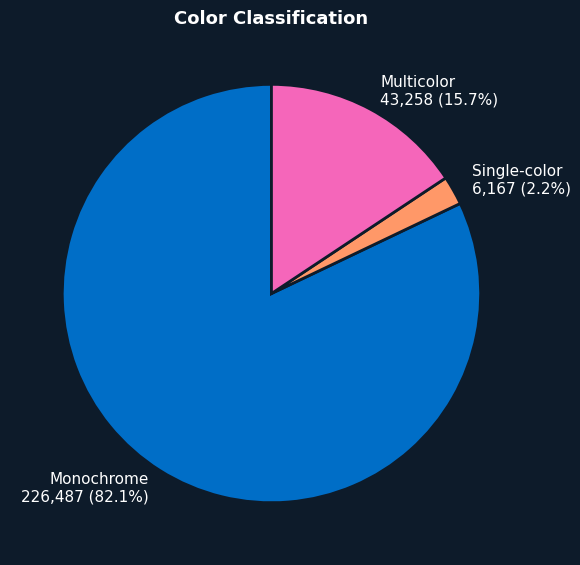

In [5]:
fig, ax = plt.subplots(figsize=(6, 6), facecolor=dark_bg)
ax.pie(
    [len(mono), len(single), len(multi)],
    labels=[
        f"Monochrome\n{len(mono):,} ({len(mono)/total*100:.1f}%)",
        f"Single-color\n{len(single):,} ({len(single)/total*100:.1f}%)",
        f"Multicolor\n{len(multi):,} ({len(multi)/total*100:.1f}%)",
    ],
    colors=[blue, orange, pink],
    startangle=90,
    wedgeprops=dict(linewidth=2, edgecolor=dark_bg),
    textprops=dict(color=white, fontsize=11),
)
ax.set_title("Color Classification", fontsize=13, color=white, fontweight="bold")
plt.tight_layout()
plt.show()

## 2. Average Path Count

In [6]:
mono_paths   = np.array([r["path_count"] for r in mono])
single_paths = np.array([r["path_count"] for r in single])
multi_paths  = np.array([r["path_count"] for r in multi])

print(f"{'':30s}  {'mean':>6}  {'median':>6}  {'max':>6}")
print("-" * 55)
print(f"{'Monochrome':30s}  {mono_paths.mean():6.1f}  {np.median(mono_paths):6.1f}  {mono_paths.max():6,}")
print(f"{'Single-color (→ currentColor)':30s}  {single_paths.mean():6.1f}  {np.median(single_paths):6.1f}  {single_paths.max():6,}")
print(f"{'Multicolor':30s}  {multi_paths.mean():6.1f}  {np.median(multi_paths):6.1f}  {multi_paths.max():6,}")

                                  mean  median     max
-------------------------------------------------------
Monochrome                         1.4     1.0      40
Single-color (→ currentColor)      1.9     1.0      25
Multicolor                        10.9     4.0     895


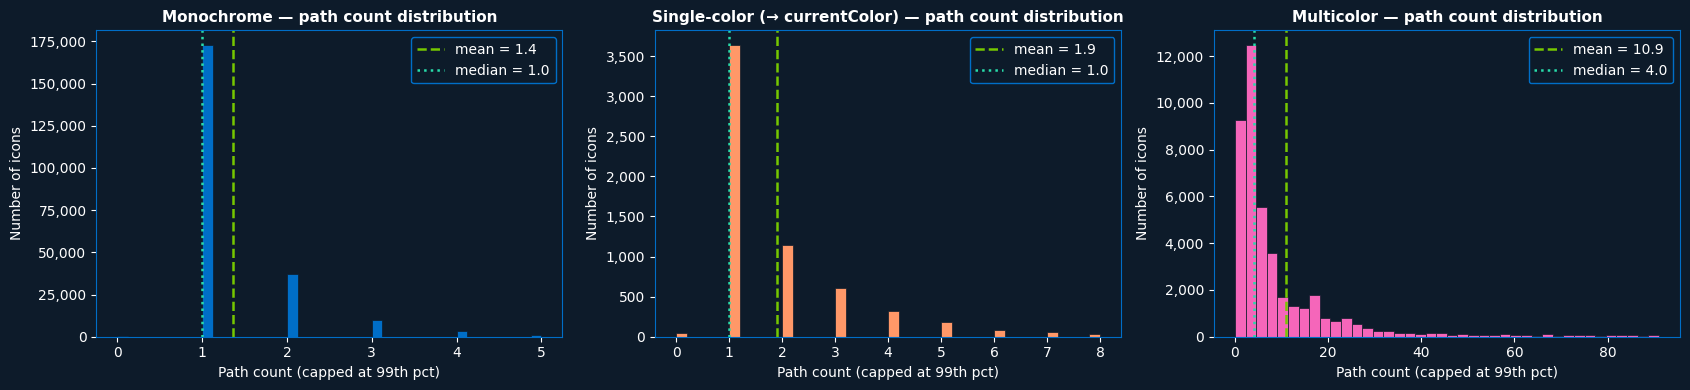

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4), facecolor=dark_bg)

for ax, paths, label, color in zip(
    axes,
    [mono_paths, single_paths, multi_paths],
    ["Monochrome", "Single-color (→ currentColor)", "Multicolor"],
    [blue, orange, pink],
):
    cap = int(np.percentile(paths, 99))
    ax.hist(paths[paths <= cap], bins=40, color=color, edgecolor=dark_bg, linewidth=0.5)
    ax.axvline(paths.mean(), color=green, linestyle="--", linewidth=1.8,
               label=f"mean = {paths.mean():.1f}")
    ax.axvline(np.median(paths), color=teal, linestyle=":", linewidth=1.8,
               label=f"median = {np.median(paths):.1f}")
    ax.set_title(f"{label} — path count distribution", fontsize=11, fontweight="bold")
    ax.set_xlabel("Path count (capped at 99th pct)")
    ax.set_ylabel("Number of icons")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
    for spine in ax.spines.values():
        spine.set_edgecolor(blue)
    ax.legend()

plt.tight_layout()
plt.show()

## 3. Average SVG String Length

In [8]:
mono_len   = np.array([len(r["svg"]) for r in mono])
single_len = np.array([len(r["svg"]) for r in single])
multi_len  = np.array([len(r["svg"]) for r in multi])

print(f"{'':30s}  {'mean':>8}  {'median':>8}  {'max':>8}  chars")
print("-" * 65)
print(f"{'Monochrome':30s}  {mono_len.mean():8.0f}  {np.median(mono_len):8.0f}  {mono_len.max():8,}")
print(f"{'Single-color (→ currentColor)':30s}  {single_len.mean():8.0f}  {np.median(single_len):8.0f}  {single_len.max():8,}")
print(f"{'Multicolor':30s}  {multi_len.mean():8.0f}  {np.median(multi_len):8.0f}  {multi_len.max():8,}")

                                    mean    median       max  chars
-----------------------------------------------------------------
Monochrome                           677       496   155,610
Single-color (→ currentColor)       1063       607   106,516
Multicolor                          4498      1446   869,523


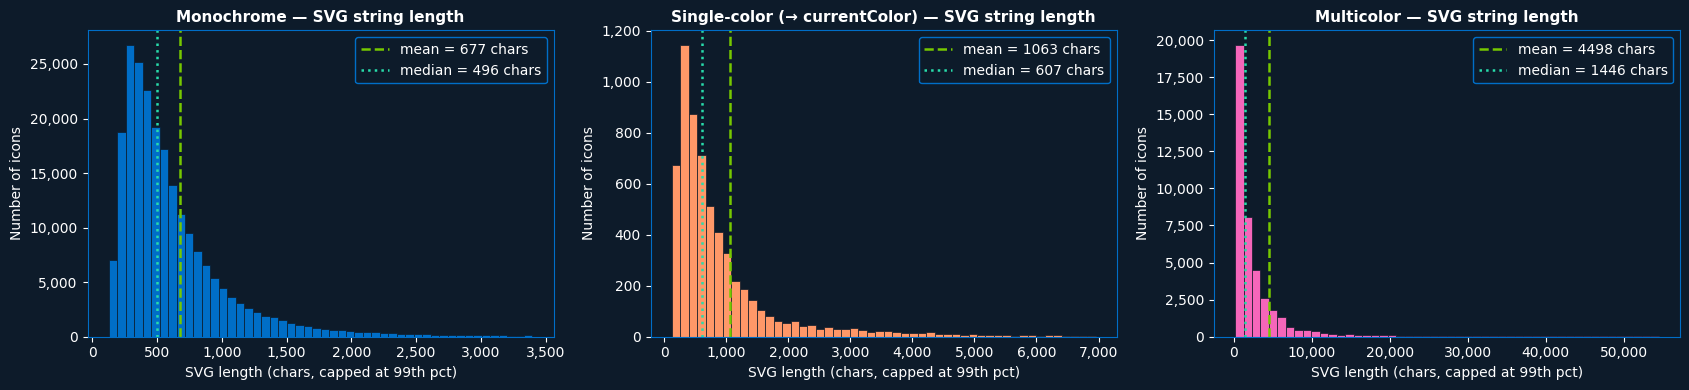

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4), facecolor=dark_bg)

for ax, lengths, label, color in zip(
    axes,
    [mono_len, single_len, multi_len],
    ["Monochrome", "Single-color (→ currentColor)", "Multicolor"],
    [blue, orange, pink],
):
    cap = int(np.percentile(lengths, 99))
    ax.hist(lengths[lengths <= cap], bins=50, color=color, edgecolor=dark_bg, linewidth=0.5)
    ax.axvline(lengths.mean(), color=green, linestyle="--", linewidth=1.8,
               label=f"mean = {lengths.mean():.0f} chars")
    ax.axvline(np.median(lengths), color=teal, linestyle=":", linewidth=1.8,
               label=f"median = {np.median(lengths):.0f} chars")
    ax.set_title(f"{label} — SVG string length", fontsize=11, fontweight="bold")
    ax.set_xlabel("SVG length (chars, capped at 99th pct)")
    ax.set_ylabel("Number of icons")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
    for spine in ax.spines.values():
        spine.set_edgecolor(blue)
    ax.legend()

plt.tight_layout()
plt.show()

## 4. Summary Table

In [10]:
import pandas as pd

summary = pd.DataFrame({
    "Category": ["Monochrome", "Single-color → currentColor", "Multicolor"],
    "Count": [len(mono), len(single), len(multi)],
    "Share (%)": [
        f"{len(mono)/total*100:.1f}",
        f"{len(single)/total*100:.1f}",
        f"{len(multi)/total*100:.1f}",
    ],
    "Avg paths": [
        f"{mono_paths.mean():.1f}",
        f"{single_paths.mean():.1f}",
        f"{multi_paths.mean():.1f}",
    ],
    "Median paths": [
        f"{np.median(mono_paths):.1f}",
        f"{np.median(single_paths):.1f}",
        f"{np.median(multi_paths):.1f}",
    ],
    "Avg SVG len (chars)": [
        f"{mono_len.mean():.0f}",
        f"{single_len.mean():.0f}",
        f"{multi_len.mean():.0f}",
    ],
    "Median SVG len": [
        f"{np.median(mono_len):.0f}",
        f"{np.median(single_len):.0f}",
        f"{np.median(multi_len):.0f}",
    ],
})

summary.set_index("Category", inplace=True)
summary

,Count,Share (%),Avg paths,Median paths,Avg SVG len (chars),Median SVG len
Category,,,,,,
Monochrome,226487,82.1,1.4,1.0,677,496
Single-color → currentColor,6167,2.2,1.9,1.0,1063,607
Multicolor,43258,15.7,10.9,4.0,4498,1446


## 5. Visual Inspection — Single-color Icons by Path Count

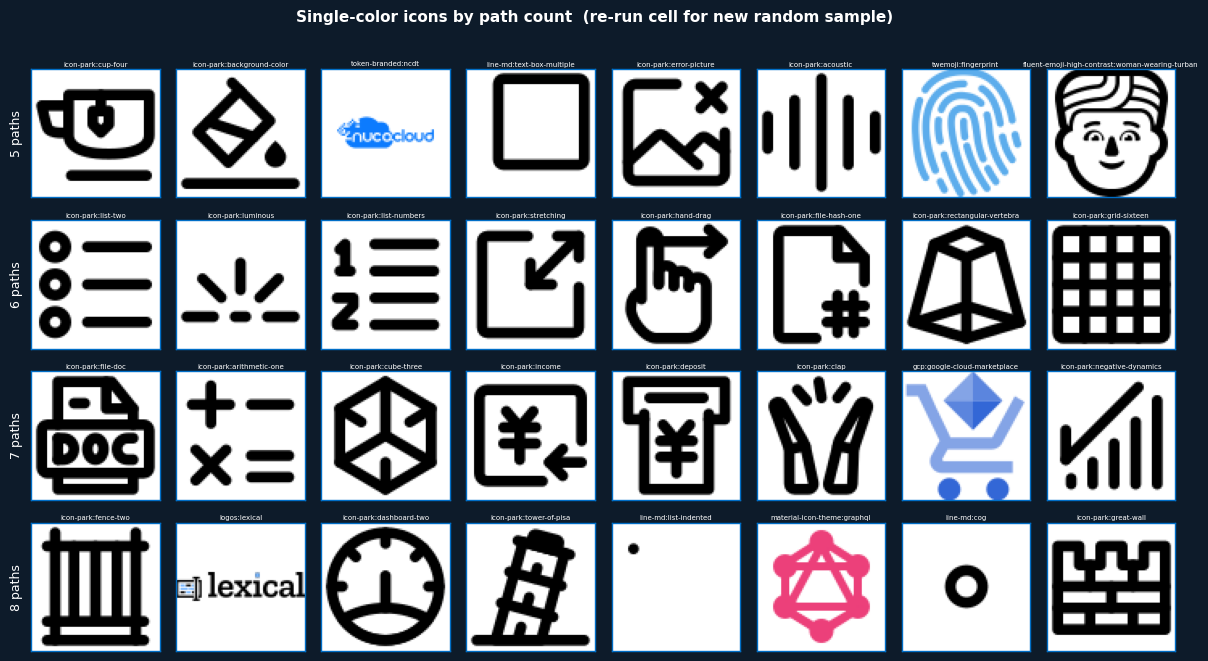

In [15]:
import io
import random
import cairosvg
from PIL import Image

def _svg_to_img(svg_str: str, size: int = 80) -> np.ndarray:
    png = cairosvg.svg2png(
        bytestring=svg_str.encode(),
        output_width=size,
        output_height=size,
        background_color="white",
    )
    return np.array(Image.open(io.BytesIO(png)).convert("RGB"))

rows_paths = [5, 6, 7, 8]
n_cols = 8

fig, axes = plt.subplots(
    len(rows_paths), n_cols,
    figsize=(n_cols * 1.5, len(rows_paths) * 1.5 + 0.5),
    facecolor=dark_bg,
)
fig.subplots_adjust(hspace=0.3, wspace=0.08)

for row_i, n_paths in enumerate(rows_paths):
    pool = [r for r in single if r["path_count"] == n_paths]
    sample = random.sample(pool, min(n_cols, len(pool))) if pool else []
    for col_i in range(n_cols):
        ax = axes[row_i, col_i]
        ax.set_facecolor("white")
        for spine in ax.spines.values():
            spine.set_edgecolor(blue)
            spine.set_linewidth(1.0)
        ax.set_xticks([])
        ax.set_yticks([])
        if col_i < len(sample):
            ax.imshow(_svg_to_img(sample[col_i]["svg"]))
            ax.set_title(sample[col_i]["icon_id"], fontsize=5, color=white, pad=2)
        if col_i == 0:
            ax.set_ylabel(f"{n_paths} paths", color=white, fontsize=9, labelpad=6)

fig.suptitle("Single-color icons by path count  (re-run cell for new random sample)",
             color=white, fontsize=11, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

## 6. Animated vs. Static

In [16]:
import pandas as pd

_ANIM_RE = re.compile(r'<animate|<set[\s>/]|@keyframes|animation\s*:', re.IGNORECASE)

for r in records:
    if "is_animated" not in r:
        r["is_animated"] = bool(_ANIM_RE.search(r["svg"]))

n_animated = sum(1 for r in records if r["is_animated"])
n_static   = total - n_animated

print(f"Static   : {n_static:>7,}  ({n_static/total*100:.1f}%)")
print(f"Animated : {n_animated:>7,}  ({n_animated/total*100:.1f}%)")
print()

cross_rows = []
for cls in ["monochrome", "single_color", "multicolor"]:
    subset = [r for r in records if r["color_class"] == cls]
    n_anim = sum(1 for r in subset if r["is_animated"])
    n_stat = len(subset) - n_anim
    cross_rows.append({
        "color_class": cls,
        "static": n_stat, "animated": n_anim,
        "total": len(subset),
        "anim_%": round(n_anim / len(subset) * 100, 2),
    })
    flag = "  ← contains animated!" if cls == "monochrome" and n_anim > 0 else ""
    print(f"  {cls:<15}  static={n_stat:>7,}  animated={n_anim:>6,}  ({n_anim/len(subset)*100:.2f}%){flag}")

cross = pd.DataFrame(cross_rows).set_index("color_class")
cross

Static   : 274,240  (99.4%)
Animated :   1,672  (0.6%)

  monochrome       static=226,442  animated=    45  (0.02%)  ← contains animated!
  single_color     static=  5,382  animated=   785  (12.73%)
  multicolor       static= 42,416  animated=   842  (1.95%)


,static,animated,total,anim_%
color_class,,,,
monochrome,226442,45,226487,0.02
single_color,5382,785,6167,12.73
multicolor,42416,842,43258,1.95


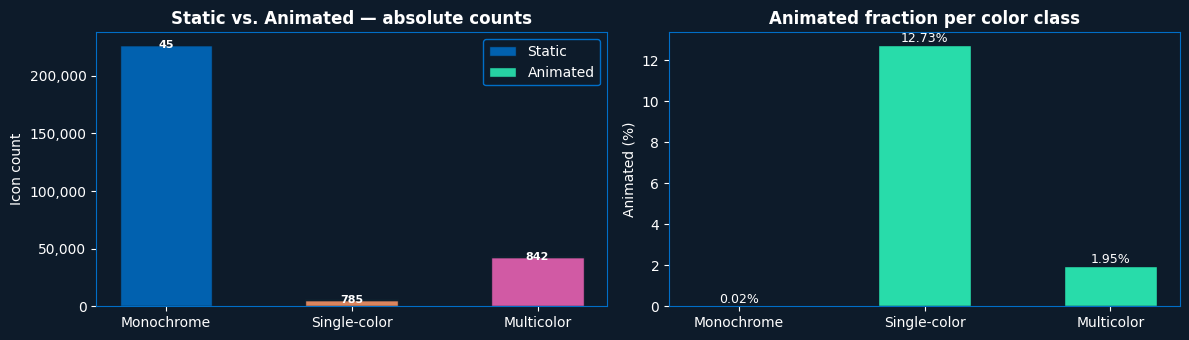

In [17]:
cats       = ["monochrome", "single_color", "multicolor"]
labels     = ["Monochrome", "Single-color", "Multicolor"]
cat_colors = [blue, orange, pink]

static_counts   = [cross.loc[c, "static"]   for c in cats]
animated_counts = [cross.loc[c, "animated"] for c in cats]
pcts            = [cross.loc[c, "anim_%"]   for c in cats]
x = np.arange(len(cats))

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5), facecolor=dark_bg)

# Left: stacked absolute counts
ax = axes[0]
ax.bar(x, static_counts, color=cat_colors, alpha=0.85, edgecolor=dark_bg, width=0.5, label="Static")
bars_a = ax.bar(x, animated_counts, color=teal, alpha=0.95, bottom=static_counts,
                edgecolor=dark_bg, width=0.5, label="Animated")
for bar, anim in zip(bars_a, animated_counts):
    if anim > 0:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_y() + bar.get_height() / 2,
                f"{anim:,}", ha="center", va="center", color=white, fontsize=8, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Icon count")
ax.set_title("Static vs. Animated — absolute counts", fontweight="bold")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{int(v):,}"))
for spine in ax.spines.values():
    spine.set_edgecolor(blue)
ax.legend()

# Right: animated % per color class
ax2 = axes[1]
bars = ax2.bar(x, pcts, color=teal, edgecolor=dark_bg, width=0.5)
for bar, pct in zip(bars, pcts):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
             f"{pct:.2f}%", ha="center", va="bottom", color=white, fontsize=9)
ax2.set_xticks(x)
ax2.set_xticklabels(labels)
ax2.set_ylabel("Animated (%)")
ax2.set_title("Animated fraction per color class", fontweight="bold")
for spine in ax2.spines.values():
    spine.set_edgecolor(blue)

plt.tight_layout()
plt.show()